# **Price Prediction** | Kota 2023

# **I. Data Understanding**

# ***A. Penjabaran Studi Kasus***

Perusahaan elektronik ingin membuat model prediksi harga jual produk TL-WR840N di Tokopedia.

# ***B. Import Libraries***

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tk

# ***C. Import Dataset***

In [35]:
dataset = pd.read_csv("skkrrr.csv")
dataset

C:\Users\USER\AppData\Local\Temp\ipykernel_18064\3915022392.py:1: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("skkrrr.csv")


,Date,Last Crawling,SKU Name,Product Name,Url Product,Seller,Merchant,Stock,Item Condition,Filter,Flag,Bottom Price,Original Price,Discount,Selling Price,Discrepancy,Sales Quantity,Sales Revenue
0,10/22/2022,10/22/2022,TL WR840N,TP-Link TL-WR840N 2 Antenna 300Mbps Wireless N...,https://tokopedia.com/ccplace/tp-link-tl-wr840...,ccplace shop,tokopedia,In Stock,baru,Above,Please Check,155000,231000,0,231000,0.014903,0,0
1,10/22/2022,10/22/2022,TL WR840N,Promo TP-LINK TL-WR840N Wireless Router 300Mbp...,https://tokopedia.com/gilsaashopp/promo-tp-lin...,gilsaa_shopp,tokopedia,In Stock,baru,Above,Please Check,155000,218800,0,218800,0.014116,0,0
2,10/22/2022,10/22/2022,TL WR840N,Tp-Link TL-WR840N 300Mbps Wireless N Speed Rou...,https://tokopedia.com/ccwinta/tp-link-tl-wr840...,ccwinta shop,tokopedia,In Stock,baru,Above,Please Check,155000,227000,0,227000,0.014645,0,0
3,10/22/2022,10/22/2022,TL WR840N,JARINGAN TP-LINK TL-WR 840N TL-WR840N 300MBps ...,https://tokopedia.com/belsa/jaringan-tp-link-t...,BELSA_SHOP,tokopedia,In Stock,baru,Above,Please Check,155000,263000,0,263000,0.016968,0,0
4,10/22/2022,10/22/2022,TL WR840N,TPLink TL-WR840N Router Wireless WiFi 300Mbps ...,https://tokopedia.com/ccwinta/tplink-tl-wr840n...,ccwinta shop,tokopedia,In Stock,baru,Above,Please Check,155000,236000,0,236000,0.015226,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32767,09/20/2022,09/20/2022,TL WR840N,KODE CVUSM02 TP-LINK TL-WR840N 300MBps Wireles...,https://tokopedia.com/cvunggulsidomukti/kode-c...,CV Unggul Sido Mukti,tokopedia,In Stock,baru,Above,Please Check,155000,244000,0,244000,0.015742,0,0
32768,09/20/2022,09/20/2022,TL WR840N,WIRELESS ROUTER TP-LINK TL-WR840N 300Mbps,https://tokopedia.com/carlton279/wireless-rout...,carlton279,tokopedia,In Stock,baru,Above,Please Check,155000,212000,0,212000,0.013677,0,0
32769,09/20/2022,09/20/2022,TL WR840N,TP-LINK TL-WR840N 300Mbps Wireless Router / Wi...,https://tokopedia.com/forgotenstore/tp-link-tl...,Forgoten Store,tokopedia,In Stock,baru,Above,Please Check,155000,271733,0,271733,0.017531,0,0
32770,09/20/2022,09/20/2022,TL WR840N,WIRELESS ROUTER TP-LINK TL-WR840N 300Mbps,https://tokopedia.com/sani1/wireless-router-tp...,Sani1_Shop,tokopedia,In Stock,baru,Above,Please Check,155000,210000,0,210000,0.013548,0,0


# **II. Data Preparation**

# ***A. Data Preparation***

### 1. Feature Engineering

#### *a. Object to Numeric*

##### **Original Price**

In [36]:
dataset['Original Price'] = (
    dataset['Original Price']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)  
    .replace('', '0')  
    .astype(int)
)

##### **Discount**

In [37]:
dataset['Discount'] = (
    dataset['Discount']
    .astype(str)
    .str.replace(r'[^\d.]', '', regex=True)  
    .replace('', '0')
    .astype(float)
)

#### **Selling Price**

In [38]:
dataset['Selling Price'] = (
    dataset['Selling Price']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)  # Hapus titik, koma, spasi
    .replace('', '0')
    .astype(int)
)

#### *b. Outliers Handling*

In [39]:
dataset_clean = dataset[
    (dataset['Selling Price'] >= 100000) &
    (dataset['Selling Price'] <= 500000) &
    (dataset['Original Price'] >= 100000) &
    (dataset['Original Price'] <= 500000)
].copy()

dataset_clean = dataset_clean.dropna(subset=['Original Price', 'Selling Price'])

len(dataset_clean)

32014

In [40]:
dataset_clean['Original Price'] = pd.to_numeric(dataset_clean['Original Price'], errors='coerce')
dataset_clean['Selling Price'] = pd.to_numeric(dataset_clean['Selling Price'], errors='coerce')

In [41]:
dataset_clean = dataset_clean.dropna(subset=['Original Price', 'Selling Price'])

### 2. Penjelasan

Setelah inspeksi awal, ditemukan adanya nilai ekstrem pada kolom Selling Price (maksimum Rp5.550.000). Oleh karena itu, data difilter agar hanya mencakup harga jual antara Rp100.000 hingga Rp500.000. Jumlah data berkurang dari 32.772 menjadi 32.093 baris.

# ***B. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [42]:
dataset.columns

Index(['Date', 'Last Crawling', 'SKU Name', 'Product Name', 'Url Product',
       'Seller', 'Merchant', 'Stock', 'Item Condition', 'Filter', 'Flag',
       'Bottom Price', 'Original Price', 'Discount', 'Selling Price',
       'Discrepancy', 'Sales Quantity', 'Sales Revenue'],
      dtype='object')

penjelasan variabel :
1. Date = tanggal pengambilan data
2. Last Crawling = kapan data terakhir diupdate
3. SKU Name = kode produk
4. Product Name = nama produk
5. Url Product = link produk
6. Seller = nama toko
7. Merchant = platform
8. Stock = persediaan barang
9. Item Condition = baru atau bekas
10. Filter = apakah harga di atas harga pabrik?
11. Flag = catatan tambahan
12. Bottom Price = harga grosir dari prabik
13. Original Price = harga awal yang dipakai toko
14. Discount = diskon
15. Selling Price = harga akhir yang dibayar pembeli
16. Disrepancy = selisih relatif antara harga jual dan harga pabrik
17. Sales Quantity = jumlah terjual
18. Sales Revenue = pendapatan

### 2. Inspeksi Informasi Ringkas

In [43]:
dataset_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32014 entries, 0 to 32771
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            32014 non-null  object 
 1   Last Crawling   32014 non-null  object 
 2   SKU Name        32014 non-null  object 
 3   Product Name    32014 non-null  object 
 4   Url Product     32014 non-null  object 
 5   Seller          32014 non-null  object 
 6   Merchant        32014 non-null  object 
 7   Stock           32014 non-null  object 
 8   Item Condition  32014 non-null  object 
 9   Filter          32014 non-null  object 
 10  Flag            32014 non-null  object 
 11  Bottom Price    32014 non-null  int64  
 12  Original Price  32014 non-null  int64  
 13  Discount        32014 non-null  float64
 14  Selling Price   32014 non-null  int64  
 15  Discrepancy     32014 non-null  float64
 16  Sales Quantity  32014 non-null  int64  
 17  Sales Revenue   32014 non-null  int6

In [44]:
num_cols = ['Bottom Price', 'Discrepancy', 'Sales Quantity', 'Sales Revenue', 'Bottom Price', 'Original Price']
cat_cols = ['Date', 'Last Crawling', 'SKU Name', 'Product Name', 'Url Product',
       'Seller', 'Merchant', 'Stock', 'Item Condition', 'Filter', 'Flag']

### 3. Inspeksi Statistik Deskriptif

In [45]:
dataset_clean.describe()

,Bottom Price,Original Price,Discount,Selling Price,Discrepancy,Sales Quantity,Sales Revenue
count,32014.0,32014.000000,32014.000000,32014.000000,32014.000000,32014.000000,3.201400e+04
mean,155000.0,254144.405698,0.000159,254104.751921,0.016257,11.617167,1.817861e+06
std,0.0,60147.980420,0.006556,60170.296786,0.004262,330.814471,5.130274e+07
min,155000.0,100000.000000,0.000000,100000.000000,0.000000,0.000000,0.000000e+00
25%,155000.0,214000.000000,0.000000,214000.000000,0.013806,0.000000,0.000000e+00
50%,155000.0,241000.000000,0.000000,241000.000000,0.015548,0.000000,0.000000e+00
75%,155000.0,282000.000000,0.000000,282000.000000,0.018194,0.000000,0.000000e+00
max,155000.0,500000.000000,0.540000,500000.000000,0.032258,33740.000000,5.229700e+09


### 4. Inspeksi Data NaN

In [46]:
dataset_clean.isna().sum()

Date              0
Last Crawling     0
SKU Name          0
Product Name      0
Url Product       0
Seller            0
Merchant          0
Stock             0
Item Condition    0
Filter            0
Flag              0
Bottom Price      0
Original Price    0
Discount          0
Selling Price     0
Discrepancy       0
Sales Quantity    0
Sales Revenue     0
dtype: int64

### 5. Inspeksi Data Duplicated

In [47]:
dataset.duplicated().sum()

np.int64(0)

### 6. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

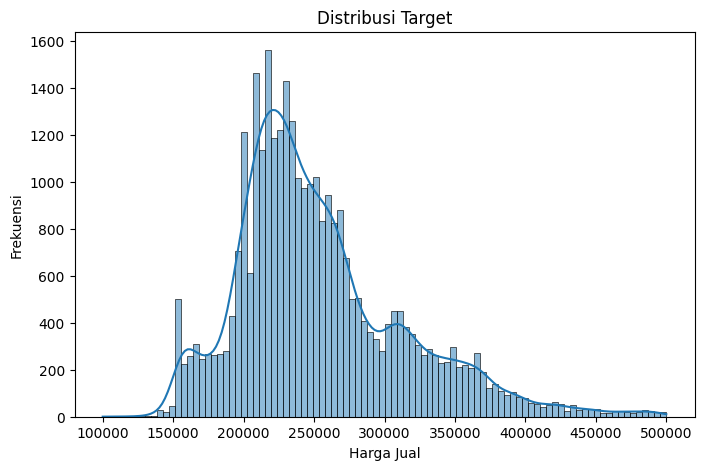

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(dataset_clean['Selling Price'], kde=True)
plt.title("Distribusi Target")
plt.xlabel("Harga Jual")
plt.ylabel("Frekuensi")
plt.show()

#### *b. Inspeksi Distribusi Kelas Fitur*

In [49]:
def check_value(cols, top_n=1):
    for col in cols:
        print(dataset_clean[col].value_counts().head(top_n))
        print("\n")

check_value(num_cols)

Bottom Price
155000    32014
Name: count, dtype: int64


Discrepancy
0.013503    557
Name: count, dtype: int64


Sales Quantity
0    30819
Name: count, dtype: int64


Sales Revenue
0    30819
Name: count, dtype: int64


Bottom Price
155000    32014
Name: count, dtype: int64


Original Price
209300    557
Name: count, dtype: int64




### 7. Bivariate Analysis

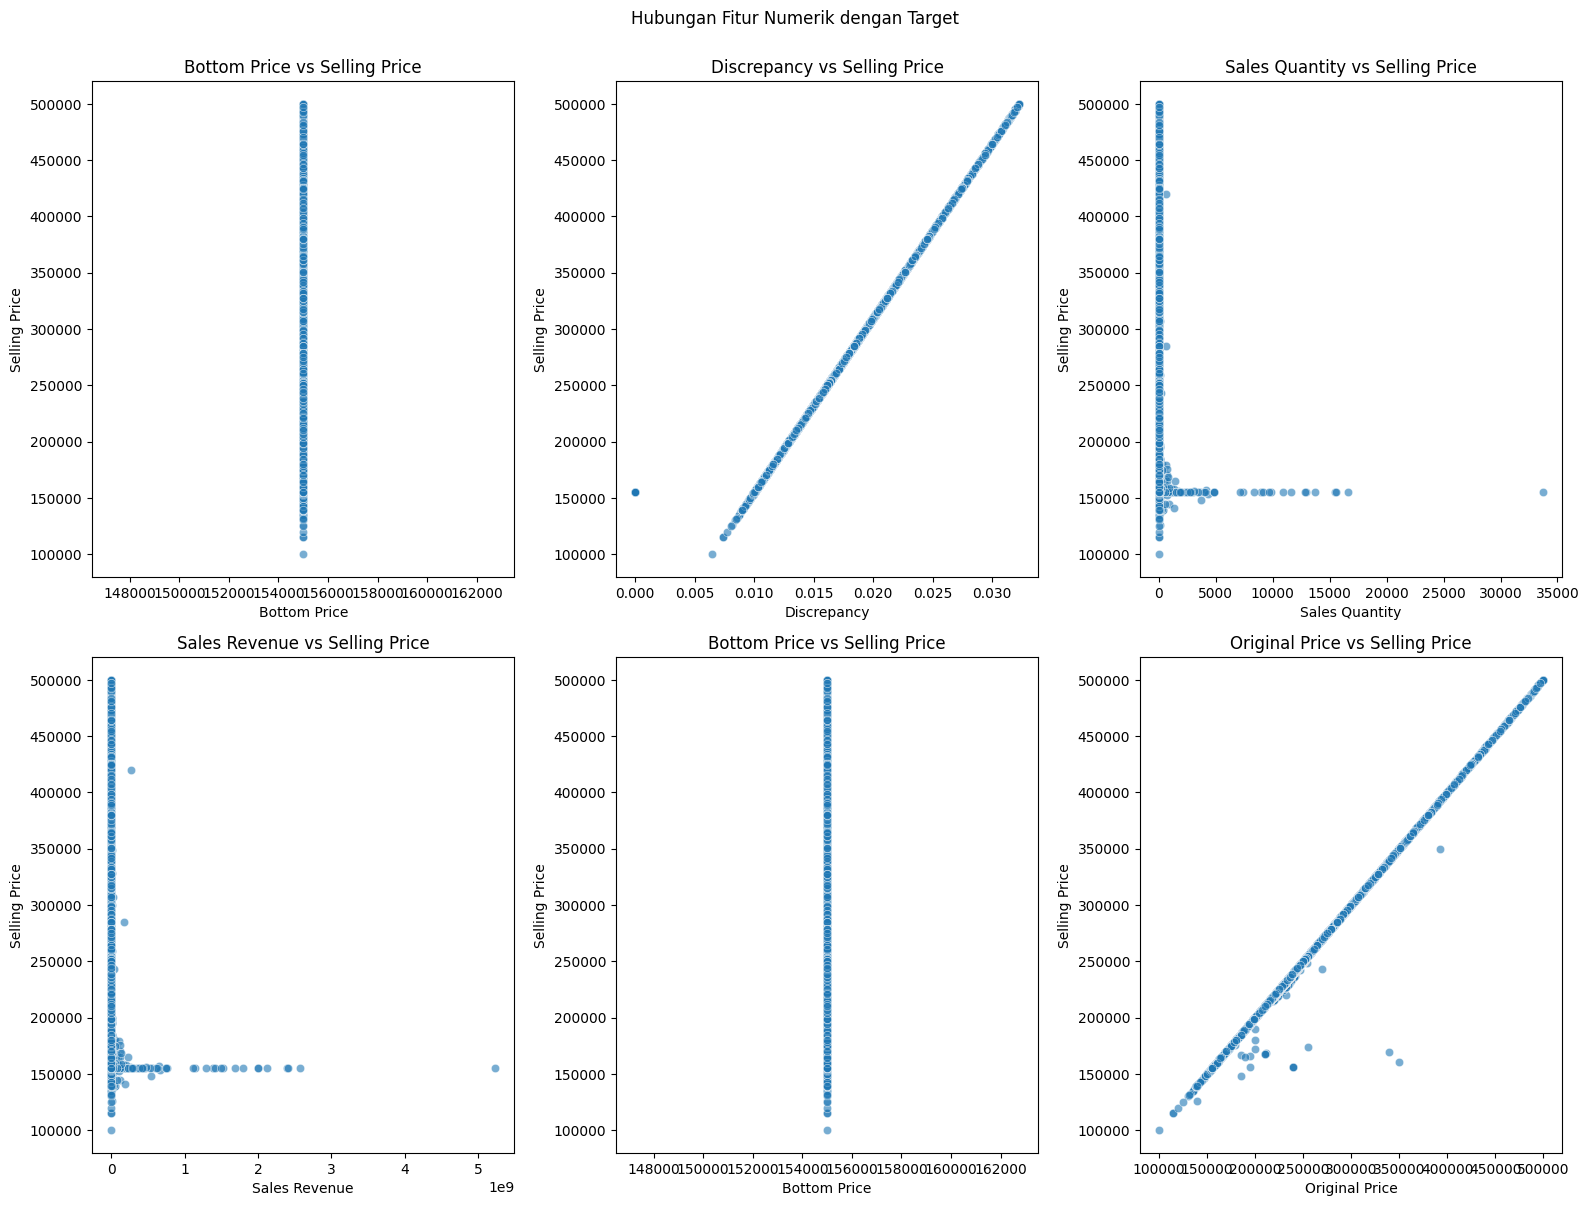

In [50]:
plt.figure(figsize=(16,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=dataset_clean[col], y=dataset_clean['Selling Price'], alpha=0.6)
    plt.title(f"{col} vs Selling Price")
    plt.xlabel(col)
    plt.ylabel("Selling Price")
plt.suptitle("Hubungan Fitur Numerik dengan Target", y=1.001)
plt.tight_layout()
plt.show()

### 8. Inspeksi Korelasi

#### *a. Pearson*

In [51]:
pearson_scores = {}
for col in num_cols:
    if col in dataset_clean.columns:
        corr = dataset_clean[col].corr(dataset_clean['Selling Price'])
        pearson_scores[col] = corr

pearson_df = pd.DataFrame(pearson_scores.items(), columns=['Feature', 'Pearson Correlation'])
pearson_df['Abs Correlation'] = pearson_df['Pearson Correlation'].abs()
pearson_df = pearson_df.sort_values('Abs Correlation', ascending=False).reset_index(drop=True)

print("\nKorelasi Pearson:")
print(pearson_df[['Feature', 'Pearson Correlation']])

best_feature = 'Original Price'  # Dipilih karena paling logis & berkorelasi tinggi
print(f"\nFitur terbaik: {best_feature}")


Korelasi Pearson:
          Feature  Pearson Correlation
0  Original Price             0.999530
1     Discrepancy             0.963598
2  Sales Quantity            -0.056978
3   Sales Revenue            -0.056778
4    Bottom Price                  NaN

Fitur terbaik: Original Price


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


# ***C. Feature and Target Declaration***

In [52]:
X = dataset_clean[best_feature].values
y = dataset_clean['Selling Price'].values

# ***D. Splitting Dataset***

In [53]:
n = len(X)
n_train = int(0.8 * n)
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

# **III. Modeling**

# ***A. Model Class***

### 1. Hitung Koefisien

In [54]:
x_mean = np.mean(X_train)
y_mean = np.mean(y_train)

numerator = np.sum((X_train - x_mean) * (y_train - y_mean))
denominator = np.sum((X_train - x_mean) ** 2)

if denominator == 0:
    slope = 0.0
else:
    slope = numerator / denominator

intercept = y_mean - slope * x_mean

print(f"\nKoefisien Regresi Linear:")
print(f"Intercept (b0) = {intercept:.2f}")
print(f"Slope     (b1) = {slope:.4f}")
print(f"\nPersamaan Model:")
print(f"Selling Price = {intercept:.2f} + {slope:.4f} * {best_feature}")


Koefisien Regresi Linear:
Intercept (b0) = -13.76
Slope     (b1) = 0.9999

Persamaan Model:
Selling Price = -13.76 + 0.9999 * Original Price


### 2. Prediksi data test

In [55]:
y_pred_train = intercept + slope * X_train
y_pred_test = intercept + slope * X_test

# ***B. Visualisasi Model***

    - Plot scatter data asli + garis regresi
    - Plot prediksi vs aktual

#### *a. Scatter + Garis Regresi*

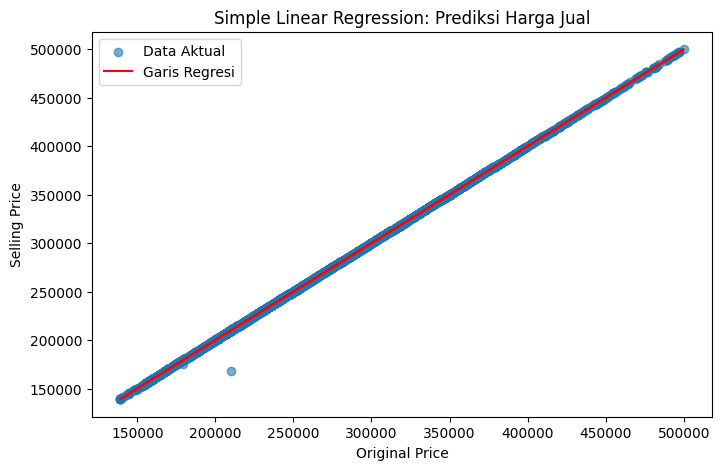

In [56]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.6, label='Data Aktual')
plt.plot(X_test, y_pred_test, color='red', label='Garis Regresi')
plt.title("Simple Linear Regression: Prediksi Harga Jual")
plt.xlabel(best_feature)
plt.ylabel("Selling Price")
plt.legend()
plt.show()

#### *b. Prediksi vs Aktual*

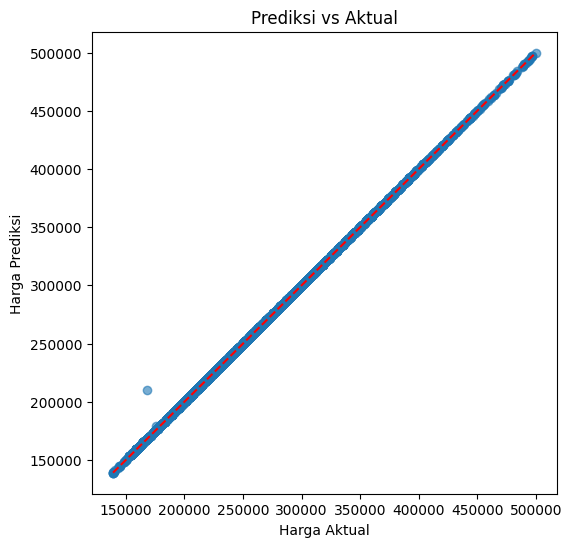

In [57]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Prediksi vs Aktual")
plt.show()

# ***C. Evaluasi Model***

    - Hitung **MSE**, **RMSE**, atau **MAE** (karena ini regresi, bukan akurasi!)
    - Bisa juga hitung **R² score** manual:
        R² = 1 - (SS_res / SS_tot)

In [58]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / (ss_tot + 1e-10))

test_mse = mse(y_test, y_pred_test)
test_rmse = rmse(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\nEvaluasi Model (Test):")
print(f"MSE  : {test_mse:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R²   : {test_r2:.4f}")


Evaluasi Model (Test):
MSE  : 279186.41
RMSE : 528.38
R²   : 0.9999


# **IV. GUI**

In [60]:
def predict_price():
    try:
        original_price = float(entry.get())
        predicted = intercept + slope * original_price
        result_label.config(text=f"Prediksi Harga Jual: Rp{predicted:,.0f}")
    except:
        result_label.config(text="Masukkan angka yang valid!")

root = tk.Tk()
root.title("Prediksi Harga TL-WR840N")
tk.Label(root, text="Masukkan Original Price:").pack(pady=5)
entry = tk.Entry(root)
entry.pack(pady=5)
tk.Button(root, text="Prediksi", command=predict_price).pack(pady=5)
result_label = tk.Label(root, text="", font=("Arial", 12, "bold"))
result_label.pack(pady=10)
root.mainloop()